### Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/weather-climate-analysis/blob/main/Weather_Analysis.ipynb)

Run every cell from the top. Upload `Weather_Data.csv` when the picker appears. The
last cell downloads the cleaned dataset, the figures and the result tables.

# Weather and Climate Pattern Analysis
### 3,271 daily observations, February 2008 to June 2017

---

## Author

**KOUAME Koffi Fidèle**
Data Analysis Internship
koffifidelek59@gmail.com

## The brief

Analyse a weather dataset, clean and prepare the data, then study temperature,
humidity, wind speed and rainfall across time periods and locations. Identify unusual
patterns, determine the most important KPIs, and build an interactive dashboard.

## What this notebook found

Every code cell is preceded by a table stating its **input**, the **method** it
applies and the **output** it produces, and every concept is defined where it is first
used.

The file has **zero missing cells, zero duplicate rows**, and passes every internal
consistency rule. A routine audit would declare it clean. Three findings say
otherwise, and none of them is visible to a missing-value count.

**1. Nearly a third of the wind record is a placeholder.** The pair *west, 41 km/h*
occurs on 1,027 days, 31.4% of the file and 32 times the next most frequent
combination. It covers **every single day of 2008 and 2009**. West is a legal
direction and 41 km/h is a legal speed, so no completeness or validity check sees it.

**2. The record is not the calendar.** 162 days in the span carry no row at all. A
missing row leaves no trace in a missing-value count, because there is no cell to be
empty. Whole months are absent.

**3. The file cannot answer the spatial question.** The brief asks for patterns across
cities and countries. There is no city, country or station column. This is a
single-station record.

## Study goals

1. **Test** the date format rather than assuming it: the wrong convention discards
   60% of the rows in silence.
2. **Detect** invented values that pass every range check, using a constant-pair test.
3. **Measure** calendar coverage, and normalise every monthly figure for it.
4. **Establish** the hemisphere from the data before assigning seasons.
5. **Test** the temperature trend rather than asserting it, and report its p-value.
6. **Verify** the submitted Power BI dashboard line by line against the data.

## Table of contents

1. [Setup](#setup)
2. [Load](#load)
3. [Diagnosis](#diag)
4. [Validation and the constant-pair test](#valid)
5. [Cleaning](#clean)
6. [Analysis](#analysis)
7. [Figures](#fig)
8. [Insights](#ins)
9. [Limitations](#lim)
10. [References](#ref)

<a id="setup"></a>
# 1. Setup

#### Cell 1. Install dependencies

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Installs the five packages used. All are present in Colab; listed so the environment is reproducible elsewhere. |
| **Output** | None. `%%capture` hides the installer log. |


In [1]:
%%capture
!pip install -q pandas numpy matplotlib scipy

#### Cell 2. Imports and figure style

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Imports the libraries, fixes the figure style once, and creates the output folders. |
| **Output** | A confirmation and three folders. |

**On the palette.** One blue ramp, with amber reserved for the value that needs attention. A categorical rainbow would imply the series differ in kind; they differ in magnitude. No reference line is dashed.


In [2]:
%matplotlib inline
import json, os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

# ---------------------------------------------------------------- house style
# One blue ramp, with amber reserved for the value that needs attention. A
# categorical rainbow would imply the series differ in kind; they differ in
# magnitude. The grid sits behind the marks, and no reference line is dashed.
# The ramp is built around #3498DB, the accent of the Power BI theme, so the
# report and the dashboard read as one piece of work. Amber is the theme's own
# #E67E22 and is reserved for the value that needs attention; it is never used
# decoratively.
NAVY, BLUE, MID, LIGHT, PALE = "#1A5276", "#3498DB", "#5DADE2", "#A9CCE3", "#D6EAF8"
AMBER, GREEN, GREY, INK = "#E67E22", "#1E8449", "#8B99AE", "#1B2A3A"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "figure.facecolor": "white",
    "savefig.facecolor": "white", "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlepad": 9,
    "axes.titlelocation": "left",
    "axes.labelsize": 10, "axes.labelcolor": "#33414F",
    "axes.edgecolor": "#B7C2CE", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E8EDF3", "grid.linewidth": 0.7,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": "#5B6876", "ytick.color": "#5B6876",
})
for folder in ["data", "figures", "results"]:
    os.makedirs(folder, exist_ok=True)
F = {}
MN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

<a id="load"></a>
# 2. Load

The loader searches twelve candidate paths and falls back to the Colab upload picker,
so the notebook runs on any machine rather than only the author's.

#### Cell 3. Locate and read the file

| | |
| :--- | :--- |
| **Input** | Nothing. |
| **Method** | Searches for the CSV, opens the Colab picker if it is absent, then reads it once and keeps the original for comparison. |
| **Output** | `raw` and `df`, 3,271 rows by 22 columns. |


In [3]:
# =============================================================================
# 1. LOAD
# -----------------------------------------------------------------------------
# INPUT  : Weather_Data.csv
# METHOD : locate the file wherever the notebook is running, then read once and
#          keep the original for the before-and-after comparison
# OUTPUT : raw and df
# =============================================================================
NAMES = ["Weather_Data.csv", "weather.csv", "data/Weather_Data.csv"]
CAND = NAMES + [f"/content/{n}" for n in NAMES] + \
       [f"/content/drive/MyDrive/{n}" for n in NAMES]
CSV = next((p for p in CAND if os.path.exists(p)), None)
if CSV is None and "google.colab" in sys.modules:
    print("Weather_Data.csv not found in this session. Please upload it now.")
    from google.colab import files
    CSV = next(iter(files.upload()))
if CSV is None:
    raise FileNotFoundError("Weather_Data.csv was not found. Searched: " + ", ".join(CAND))

raw = pd.read_csv(CSV)
df = raw.copy()
F["rows_raw"], F["cols_raw"] = len(df), df.shape[1]
print(f"Loaded {len(df):,} daily observations, {df.shape[1]} columns from {CSV}")

Loaded 3,271 daily observations, 22 columns from Weather_Data.csv


<a id="diag"></a>
# 3. Diagnosis, before anything is changed

Nothing is modified here. Diagnosing after correcting reports the wrong counts.

The routine checks run first, then two that a completeness audit cannot perform:
whether the record covers the calendar it claims to, and whether the file can answer
the question the brief asks.

**Term.** A *completeness audit* counts empty cells. It cannot see a day that was
never written at all, because there is no cell to be empty. That distinction is the
whole of section 3.3.

#### Cell 4. Diagnose

| | |
| :--- | :--- |
| **Input** | `df` as supplied. |
| **Method** | Counts missing cells and duplicates, tests both date conventions, then compares the observed dates against the full calendar span. |
| **Output** | The diagnosis block of `F`. |

**On the date format.** Read as `m/d/Y` the column parses completely; read as `d/m/Y` it leaves 1,974 rows unparsed, 60% of the file. A single conversion call with the wrong assumption would discard those rows without raising anything.


In [4]:
# =============================================================================
# 2. DIAGNOSIS, before anything is changed
# -----------------------------------------------------------------------------
# INPUT  : df as supplied
# METHOD : the routine checks, then two that a completeness audit does not
#          perform: whether the record covers the calendar it claims to, and
#          whether the file can answer the question the brief asks.
# OUTPUT : the diagnosis block of F
#
# Term. A COMPLETENESS AUDIT counts empty cells. It cannot see a day that was
# never written at all: a missing row leaves no trace in a missing-value count.
# The distinction matters here, because this file has zero empty cells and is
# still not a complete record.
# =============================================================================
F["missing_cells"] = int(df.isna().sum().sum())
F["dup_rows"] = int(df.duplicated().sum())

# 2.1 Does the file answer the brief?
LOC_WORDS = ("city", "country", "location", "station", "region", "lat", "lon")
F["has_location"] = any(any(w in c.lower() for w in LOC_WORDS) for c in df.columns)
print(f"Missing cells : {F['missing_cells']}")
print(f"Duplicate rows: {F['dup_rows']}")
print(f"\nLocation column present: {F['has_location']}")
if not F["has_location"]:
    print("  The brief asks for patterns 'across different cities and countries'.")
    print("  This file carries no city, country or station column. It is a single-")
    print("  station daily record, so no spatial comparison is possible.")

# 2.2 Dates. The column is text; the format is checked rather than assumed.
s = df.Date.astype("string").str.strip()
p_us = pd.to_datetime(s, format="%m/%d/%Y", errors="coerce")
p_eu = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
F["date_fmt_us_fail"] = int(p_us.isna().sum())
F["date_fmt_eu_fail"] = int(p_eu.isna().sum())
print(f"\nDate format audit: m/d/Y leaves {F['date_fmt_us_fail']} unparsed, "
      f"d/m/Y leaves {F['date_fmt_eu_fail']}.")
print("  The file is m/d/Y. Reading it as d/m/Y would silently discard 60% of the rows.")
df["Date"] = p_us

# 2.3 Calendar coverage. This is the finding a completeness audit cannot reach.
span = pd.date_range(df.Date.min(), df.Date.max(), freq="D")
gaps = span.difference(df.Date)
F["date_min"], F["date_max"] = str(df.Date.min().date()), str(df.Date.max().date())
F["span_days"], F["observed_days"] = len(span), int(df.Date.nunique())
F["missing_days"] = int(len(gaps))
F["missing_days_pct"] = round(100*len(gaps)/len(span), 1)
runs, cur = [], [gaps[0]]
for a, b in zip(gaps[:-1], gaps[1:]):
    if (b - a).days == 1: cur.append(b)
    else: runs.append(cur); cur = [b]
runs.append(cur); runs.sort(key=len, reverse=True)
F["longest_gaps"] = [{"start": str(r[0].date()), "days": len(r)} for r in runs[:4]]
print(f"\nCalendar span : {F['date_min']} to {F['date_max']}, {F['span_days']} days")
print(f"Days observed : {F['observed_days']}")
print(f"DAYS ABSENT   : {F['missing_days']} ({F['missing_days_pct']}% of the span)")
print("  Longest runs:", ", ".join(f"{g['start']} for {g['days']} days"
                                   for g in F["longest_gaps"][:3]))
print("  Whole months are absent. Any monthly total is therefore a total over an")
print("  unequal number of observed days, which section 5 corrects for.")

Missing cells : 0
Duplicate rows: 0

Location column present: False
  The brief asks for patterns 'across different cities and countries'.
  This file carries no city, country or station column. It is a single-
  station daily record, so no spatial comparison is possible.

Date format audit: m/d/Y leaves 0 unparsed, d/m/Y leaves 1974.
  The file is m/d/Y. Reading it as d/m/Y would silently discard 60% of the rows.

Calendar span : 2008-02-01 to 2017-06-25, 3433 days
Days observed : 3271
DAYS ABSENT   : 162 (4.7% of the span)
  Longest runs: 2012-12-01 for 31 days, 2011-04-01 for 30 days, 2013-02-01 for 28 days
  Whole months are absent. Any monthly total is therefore a total over an
  unequal number of observed days, which section 5 corrects for.


<a id="valid"></a>
# 4. Validation and the constant-pair test

Six physical and consistency rules run first. All pass except one cloud value.

Then the test that matters. **A consistency rule cannot catch a value that is valid
but invented.** The constant-pair test looks for a direction-and-speed combination
that repeats more often than weather allows. Wind gust is the natural candidate:
direction and speed come from one instrument, so when it fails both are filled
together.

**Term.** A *constant-pair placeholder* is a fixed value written into a record when an
instrument reported nothing. It passes every range check, every type check and every
completeness audit, because it is a legal value in the right column.

#### Cell 5. Validate and test for placeholders

| | |
| :--- | :--- |
| **Input** | `df` with the dates parsed. |
| **Method** | Six bound and consistency rules, then the constant-pair frequency test on wind gust, broken down by year. |
| **Output** | The validation block of `F` and the `PLACEHOLDER` mask. |

**The finding.** The pair *west, 41 km/h* occurs 1,027 times, 32 times the next most frequent pair, and covers 100% of 2008 and 2009. Wind gust is treated as unusable before 2011.


In [5]:
# =============================================================================
# 3. VALIDATION
# -----------------------------------------------------------------------------
# INPUT  : df with the dates parsed
# METHOD : physical bounds and internal consistency rules. A weather record has
#          relations that must hold whatever the weather did.
# OUTPUT : the validation block of F
#
# Terms used here
#   Okta       the unit of cloud cover, an integer from 0 (clear) to 8 (overcast).
#              A value of 9 exists in some archives as a code for "sky obscured",
#              and it is not a quantity: averaging it would bias the mean upward.
#   hPa        hectopascal, the unit of atmospheric pressure. Sea-level pressure
#              sits near 1013 and has never been recorded outside 870 to 1085.
# =============================================================================
V = {
 "maxtemp_below_mintemp": int((df.MaxTemp < df.MinTemp).sum()),
 "humidity_out_of_range": int(((df[["Humidity9am","Humidity3pm"]] < 0) |
                               (df[["Humidity9am","Humidity3pm"]] > 100)).any(axis=1).sum()),
 "cloud_out_of_range":    int(((df[["Cloud9am","Cloud3pm"]] < 0) |
                               (df[["Cloud9am","Cloud3pm"]] > 8)).any(axis=1).sum()),
 "pressure_implausible":  int(((df[["Pressure9am","Pressure3pm"]] < 870) |
                               (df[["Pressure9am","Pressure3pm"]] > 1085)).any(axis=1).sum()),
 "rainfall_negative":     int((df.Rainfall < 0).sum()),
 "windspeed_negative":    int((df[["WindSpeed9am","WindSpeed3pm"]] < 0).any(axis=1).sum()),
 "raintoday_mismatch":    int(((df.Rainfall > 1.0) != (df.RainToday == "Yes")).sum()),
}

# 3.1 CONSTANT-PAIR DETECTION
# -----------------------------------------------------------------------------
# A consistency rule cannot catch a value that is valid but invented. This test
# looks for a (direction, speed) pair that repeats far more often than weather
# allows. Wind gust is the natural candidate: direction and speed are measured by
# one instrument, so when it fails both are filled together.
#
# Term. A CONSTANT-PAIR PLACEHOLDER is a fixed value written into a record when an
# instrument reported nothing. It passes every range check, every type check and
# every completeness audit, because it is a legal value in the right column.
combo = df.groupby(["WindGustDir", "WindGustSpeed"]).size().sort_values(ascending=False)
top_dir, top_spd = combo.index[0]
n_top, n_next = int(combo.iloc[0]), int(combo.iloc[1])
PLACEHOLDER = (df.WindGustDir == top_dir) & (df.WindGustSpeed == top_spd)
F["wind_placeholder"] = {
    "direction": str(top_dir), "speed": float(top_spd),
    "rows": int(PLACEHOLDER.sum()),
    "pct": round(100*float(PLACEHOLDER.mean()), 1),
    "next_pair_rows": n_next,
    "ratio_to_next": round(n_top / n_next, 0),
}
by_year = df.groupby("Year" if "Year" in df else df.Date.dt.year).size()
ph_year = PLACEHOLDER.groupby(df.Date.dt.year).sum()
share = (100*ph_year/by_year).round(1)
F["wind_placeholder"]["by_year"] = {int(k): float(v) for k, v in share.items()}
F["wind_placeholder"]["years_fully_affected"] = [int(y) for y, v in share.items() if v >= 99]
F["wind_reliable_from"] = int(min([y for y, v in share.items() if v < 20]))

print("\nCONSTANT-PAIR TEST on wind gust")
print(f"  The pair ({top_dir}, {top_spd:.0f} km/h) occurs {n_top} times, "
      f"{n_top/n_next:.0f}x the next most frequent pair ({n_next}).")
print(f"  That is {100*PLACEHOLDER.mean():.1f}% of the file. This is not weather.")
print("  Share of each year carrying it:")
for y, v in share.items():
    mark = "   <-- every single day" if v >= 99 else ""
    print(f"    {y}  {v:5.1f}%{mark}")
print(f"  Wind gust is treated as unusable before {F['wind_reliable_from']}.")

F["validation"] = V
print("\nINTERNAL CONSISTENCY")
for k, n in V.items():
    print(f"  {k:<26} {n:>5}")
print("\n  RainToday is defined as rainfall above 1 mm. It agrees with the Rainfall")
print("  column on every row, so the flag is derived and not independently recorded.")


CONSTANT-PAIR TEST on wind gust
  The pair (W, 41 km/h) occurs 1027 times, 32x the next most frequent pair (32).
  That is 31.4% of the file. This is not weather.
  Share of each year carrying it:
    2008  100.0%   <-- every single day
    2009  100.0%   <-- every single day
    2010   79.6%
    2011    2.7%
    2012    2.5%
    2013    4.7%
    2014    1.1%
    2015    3.6%
    2016    5.0%
    2017    0.6%
  Wind gust is treated as unusable before 2011.

INTERNAL CONSISTENCY
  maxtemp_below_mintemp          0
  humidity_out_of_range          0
  cloud_out_of_range             1
  pressure_implausible           0
  rainfall_negative              0
  windspeed_negative             0
  raintoday_mismatch             0

  RainToday is defined as rainfall above 1 mm. It agrees with the Rainfall
  column on every row, so the flag is derived and not independently recorded.


<a id="clean"></a>
# 5. Cleaning

One decision per problem, each with its count and its reason.

| Item | Count | Decision |
| :--- | ---: | :--- |
| Date format | 3,271 | Parsed as `m/d/Y` after testing both |
| Cloud cover of 9 | 1 | Set to missing, not to 8 |
| Absent calendar days | 162 | **Not filled**: interpolating would invent 162 observations |
| Wind gust placeholder | 1,027 | Flagged, not deleted; excluded from wind figures |
| Seasons | all | Southern-hemisphere convention, established from the data |
| Incomplete years | 2 | 2012 and 2017 excluded from year-on-year comparison only |

**On the cloud value.** The okta scale runs 0 to 8. A value of 9 is used in some
archives to mean the sky was obscured, which is not the same as overcast. Setting it
to 8 would invent an observation that was never made.

#### Cell 6. Clean and derive

| | |
| :--- | :--- |
| **Input** | `df`, validated. |
| **Method** | Applies each decision, adds nine derived measures, assigns the season from the observed annual cycle, and flags the years with enough coverage to compare. |
| **Output** | A cleaned `df` and `data/weather_clean.csv`. |

**On the hemisphere.** The warmest month is January and the coolest July, so December to February is summer. Applying the northern convention would label the hottest quarter winter and invert every seasonal conclusion in the study.


In [6]:
# =============================================================================
# 4. CLEANING
# -----------------------------------------------------------------------------
# INPUT  : df, validated
# METHOD : one decision per problem, each with its count and its reason
# OUTPUT : a cleaned df and data/weather_clean.csv
# =============================================================================
print("\n" + "="*66 + "\nCLEANING\n" + "="*66)

# 4.1 The single out-of-range cloud value. It is set to missing rather than to 8:
# an okta of 9 means the sky was obscured, which is not the same as overcast, and
# treating it as 8 would invent an observation.
bad_cloud = ((df.Cloud9am > 8) | (df.Cloud3pm > 8))
F["cloud_flagged"] = int(bad_cloud.sum())
df.loc[df.Cloud9am > 8, "Cloud9am"] = np.nan
df.loc[df.Cloud3pm > 8, "Cloud3pm"] = np.nan
print(f"4.1 Cloud cover: {F['cloud_flagged']} value(s) above the 0 to 8 okta scale set to "
      "missing, not to 8. A code of 9 means the sky was obscured, not overcast.")

# 4.2 Derived measures. Each is defined once here so no chart can define it
# differently later.
df["AvgTemp"]   = (df.MinTemp + df.MaxTemp) / 2      # the daily mean of the two extremes
df["TempRange"] = df.MaxTemp - df.MinTemp            # diurnal range
df["Humidity"]  = (df.Humidity9am + df.Humidity3pm) / 2
df["WindSpeed"] = (df.WindSpeed9am + df.WindSpeed3pm) / 2
df["Pressure"]  = (df.Pressure9am + df.Pressure3pm) / 2
df["Cloud"]     = df[["Cloud9am","Cloud3pm"]].mean(axis=1)
df["Year"], df["Month"] = df.Date.dt.year, df.Date.dt.month
df["MonthName"] = df.Month.map(lambda m: MN[m-1])
df["DayOfYear"] = df.Date.dt.dayofyear
df["IsRainy"]   = df.RainToday == "Yes"

# 4.3 Season. The record is southern hemisphere: the warmest month is January and
# the coolest is July, so December to February is summer. Using the northern
# convention would label the hottest quarter "winter" and invert every seasonal
# conclusion in the study.
SEASON = {12:"Summer", 1:"Summer", 2:"Summer", 3:"Autumn", 4:"Autumn", 5:"Autumn",
          6:"Winter", 7:"Winter", 8:"Winter", 9:"Spring", 10:"Spring", 11:"Spring"}
df["Season"] = df.Month.map(SEASON)
warm, cool = df.groupby("Month").AvgTemp.mean().idxmax(), df.groupby("Month").AvgTemp.mean().idxmin()
F["warmest_month"], F["coolest_month"] = MN[warm-1], MN[cool-1]
print(f"4.2 Nine derived measures added.")
print(f"4.3 Southern-hemisphere seasons applied: warmest month is {F['warmest_month']}, "
      f"coolest is {F['coolest_month']}.")

# 4.4 Coverage flag. A year with fewer than 330 observed days cannot be compared
# with a full one, and 2017 stops in June.
cov = df.groupby("Year").size()
F["coverage_by_year"] = {int(k): int(v) for k, v in cov.items()}
COMPLETE = sorted(cov[cov >= 330].index.tolist())
F["complete_years"] = COMPLETE
df["YearComplete"] = df.Year.isin(COMPLETE)
print(f"4.4 Years with at least 330 observed days: {COMPLETE}.")
print(f"    Excluded from any year-on-year comparison: "
      f"{sorted(set(cov.index) - set(COMPLETE))}.")

df.to_csv("data/weather_clean.csv", index=False)
F["rows_clean"], F["cols_clean"] = len(df), df.shape[1]
print(f"\nClean table written: {len(df):,} rows x {df.shape[1]} columns. No row deleted.")


CLEANING
4.1 Cloud cover: 1 value(s) above the 0 to 8 okta scale set to missing, not to 8. A code of 9 means the sky was obscured, not overcast.
4.2 Nine derived measures added.
4.3 Southern-hemisphere seasons applied: warmest month is Jan, coolest is Jul.
4.4 Years with at least 330 observed days: [2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016].
    Excluded from any year-on-year comparison: [2012, 2017].

Clean table written: 3,271 rows x 35 columns. No row deleted.


<a id="analysis"></a>
# 6. Analysis

## The correction that runs through this section

Section 3 established that 162 calendar days are absent and that whole months are
missing. A monthly **total** is therefore a total over an unequal number of observed
days: the best-covered month carries 29% more observations than the worst.

Every monthly rainfall figure below is reported **both ways**, as a raw total and as
millimetres per observed day, and a conclusion is accepted only where the two agree.

## The trend, tested rather than asserted

**Term.** An *ordinary least squares trend* fits a straight line to the annual means
and reports its slope. The *p-value* is the probability of seeing a slope at least
this steep if the true slope were zero. Below 0.05 it is called significant, which
means only that it is unlikely to be noise, not that it will continue.

#### Cell 7. Compute the indicators and the patterns

| | |
| :--- | :--- |
| **Input** | The cleaned `df`. |
| **Method** | Eleven KPIs, the monthly and seasonal profiles both ways, the wind rose on reliable days only, the trend regression, the extremes and the correlation matrix. |
| **Output** | The KPI block of `F` and five tables in `results/`. |

**On the wind.** The rose is computed on the 2,244 reliable days. Including the placeholder days returns 43.6% for west, which is the backfill speaking rather than the site.


In [7]:
# =============================================================================
# 5. ANALYSIS
# -----------------------------------------------------------------------------
# INPUT  : the cleaned df
# METHOD : the indicators a weather platform reports, then the monthly and
#          seasonal profiles, the wind rose, and a trend test.
# OUTPUT : the KPI block of F and the tables in results/
#
# The correction that matters. Section 2 established that 162 calendar days are
# absent and that whole months are missing. A monthly TOTAL is therefore a total
# over an unequal number of observed days: the best-covered month carries 29%
# more observations than the worst. Every monthly rainfall figure below is
# reported both ways, as a raw total and as millimetres per observed day, and the
# conclusion is only accepted where both agree.
# =============================================================================
print("\n" + "="*66 + "\nANALYSIS\n" + "="*66)

K = {
 "avg_temp":     round(float(df.AvgTemp.mean()), 2),
 "max_temp":     round(float(df.MaxTemp.max()), 2),
 "min_temp":     round(float(df.MinTemp.min()), 2),
 "avg_humidity": round(float(df.Humidity.mean()), 2),
 "avg_wind":     round(float(df.WindSpeed.mean()), 2),
 "max_gust":     round(float(df.WindGustSpeed.max()), 0),
 "avg_gust_reliable": None,  # filled after the placeholder is known
 "total_rain":   round(float(df.Rainfall.sum()), 1),
 "rainy_days":   int(df.IsRainy.sum()),
 "rainy_pct":    round(100*float(df.IsRainy.mean()), 1),
 "avg_pressure": round(float(df.Pressure.mean()), 1),
 "avg_sunshine": round(float(df.Sunshine.mean()), 2),
 "observations": int(len(df)),
}
F["kpi"] = K
print("\nKEY INDICATORS")
for k, v in K.items(): print(f"  {k:<14} {v}")

# Monthly profile, both ways.
m = df.groupby("Month").agg(
        days=("Rainfall","size"), rain_total=("Rainfall","sum"),
        rainy=("IsRainy","sum"), temp=("AvgTemp","mean"),
        tmax=("MaxTemp","mean"), tmin=("MinTemp","mean"),
        humidity=("Humidity","mean"), wind=("WindSpeed","mean"),
        sunshine=("Sunshine","mean"))
m["rain_per_day"] = m.rain_total / m.days
m["rainy_pct"] = 100 * m.rainy / m.days
m.index = [MN[i-1] for i in m.index]
m.round(2).to_csv("results/monthly_profile.csv")
F["monthly"] = m.round(2).reset_index().rename(columns={"index":"month"}).to_dict("records")
F["coverage_spread_pct"] = round(100*(m.days.max()/m.days.min() - 1), 0)

F["wettest_total"]   = m.rain_total.idxmax()
F["wettest_per_day"] = m.rain_per_day.idxmax()
F["driest_total"]    = m.rain_total.idxmin()
F["driest_per_day"]  = m.rain_per_day.idxmin()
F["rain_per_day_max"] = round(float(m.rain_per_day.max()), 2)
F["rain_per_day_min"] = round(float(m.rain_per_day.min()), 2)
F["rank_agrees"] = (F["wettest_total"] == F["wettest_per_day"]
                    and F["driest_total"] == F["driest_per_day"])
print(f"\nMONTHLY RAINFALL, the two rankings")
print(f"  observed days per month range from {m.days.min():.0f} to {m.days.max():.0f} "
      f"({F['coverage_spread_pct']:.0f}% spread)")
print(f"  wettest by raw total   : {F['wettest_total']}")
print(f"  wettest per observed day: {F['wettest_per_day']} ({F['rain_per_day_max']} mm/day)")
print(f"  driest  by raw total   : {F['driest_total']}")
print(f"  driest  per observed day: {F['driest_per_day']} ({F['rain_per_day_min']} mm/day)")
print("  The two rankings AGREE, so the conclusion holds." if F["rank_agrees"]
      else "  The two rankings DISAGREE: the raw total is an artefact of coverage.")

# Seasonal profile.
sea = df.groupby("Season").agg(days=("Rainfall","size"), temp=("AvgTemp","mean"),
        rain_total=("Rainfall","sum"), humidity=("Humidity","mean"),
        wind=("WindSpeed","mean"))
sea["rain_per_day"] = sea.rain_total / sea.days
sea = sea.reindex(["Summer","Autumn","Winter","Spring"])
sea.round(2).to_csv("results/seasonal_profile.csv")
F["seasonal"] = sea.round(2).reset_index().to_dict("records")
F["warmest_season"] = sea.temp.idxmax()
F["wettest_season"] = sea.rain_per_day.idxmax()
print(f"\nSEASONS  warmest {F['warmest_season']} ({sea.temp.max():.1f} C), "
      f"wettest {F['wettest_season']} ({sea.rain_per_day.max():.2f} mm/day)")
print(sea.round(2).to_string())

# Humidity: when does it actually peak?
hm = df.groupby("Month").Humidity.mean()
F["humidity_peak_month"] = MN[hm.idxmax()-1]
F["humidity_low_month"]  = MN[hm.idxmin()-1]
F["humidity_peak_season"] = SEASON[hm.idxmax()]
print(f"\nHUMIDITY peaks in {F['humidity_peak_month']} ({hm.max():.1f}%), which is "
      f"{F['humidity_peak_season']}; lowest in {F['humidity_low_month']} ({hm.min():.1f}%)")

# Wind rose, computed on the reliable rows only.
# Including the placeholder days would report the placeholder's own direction as
# the prevailing wind. On the full file that produces 43.6% for W, which is an
# artefact of the backfill and not a property of the site.
wd_all = df.WindGustDir.value_counts()
wd = df.loc[~PLACEHOLDER, "WindGustDir"].value_counts()
n_rel = int((~PLACEHOLDER).sum())
F["wind_reliable_days"] = n_rel
F["dominant_wind"] = wd.index[0]
F["dominant_wind_pct"] = round(100*wd.iloc[0]/n_rel, 1)
F["dominant_wind_naive_pct"] = round(100*wd_all.iloc[0]/len(df), 1)
F["wind_second"] = wd.index[1]
F["wind_second_pct"] = round(100*wd.iloc[1]/n_rel, 1)
F["wind_dir_counts"] = {k: int(v) for k, v in wd.items()}
F["wind_se_pct"] = round(100*float(wd.get("SE", 0))/n_rel, 1)
print(f"\nWIND, on the {n_rel} reliable days")
print(f"  dominant {F['dominant_wind']} at {F['dominant_wind_pct']}%, "
      f"{F['wind_second']} second at {F['wind_second_pct']}%")
print(f"  On the full file the same calculation returns {F['dominant_wind_naive_pct']}% "
      "for W, which is the placeholder speaking, not the wind.")

# --- Trend test ---------------------------------------------------------------
# Term. An ORDINARY LEAST SQUARES trend fits a straight line to the annual means
# and reports its slope. The p-value is the probability of seeing a slope at
# least this steep if the true slope were zero. Below 0.05 the slope is called
# statistically significant, which means only that it is unlikely to be noise,
# not that it will continue.
ann = df[df.YearComplete].groupby("Year").agg(
        temp=("AvgTemp","mean"), tmax=("MaxTemp","mean"), tmin=("MinTemp","mean"),
        rain=("Rainfall","mean"), humidity=("Humidity","mean"), days=("AvgTemp","size"))
ann.round(3).to_csv("results/annual_means.csv")
sl, ic, r, p, se = stats.linregress(ann.index, ann.temp)
F["trend"] = {"slope_c_per_year": round(float(sl), 4), "p_value": round(float(p), 4),
              "r_squared": round(float(r**2), 3), "n_years": int(len(ann)),
              "decade_c": round(float(sl*10), 2),
              "significant": bool(p < 0.05)}
F["annual_means"] = ann.round(2).reset_index().to_dict("records")
print(f"\nTREND on the {len(ann)} complete years")
print(f"  slope {sl:+.4f} C per year, that is {sl*10:+.2f} C per decade")
print(f"  p = {p:.3f}, r squared = {r**2:.3f}")
print("  Statistically significant at the 5% level." if p < 0.05 else
      "  Not statistically significant.")
print(f"  Caution: this is a regression on {len(ann)} annual points. It describes this")
print("  record; it is not a climate projection and the interval is too short for one.")

# --- Extremes -----------------------------------------------------------------
E = {
 "hottest":  (str(df.loc[df.MaxTemp.idxmax(), "Date"].date()), float(df.MaxTemp.max())),
 "coldest":  (str(df.loc[df.MinTemp.idxmin(), "Date"].date()), float(df.MinTemp.min())),
 "wettest":  (str(df.loc[df.Rainfall.idxmax(), "Date"].date()), float(df.Rainfall.max())),
 "windiest": (str(df.loc[df.WindGustSpeed.idxmax(), "Date"].date()), float(df.WindGustSpeed.max())),
 "most_humid": (str(df.loc[df.Humidity9am.idxmax(), "Date"].date()), float(df.Humidity9am.max())),
}
F["extremes"] = E
print("\nEXTREMES")
for k, (dte, v) in E.items(): print(f"  {k:<11} {dte}   {v}")

# --- Correlations -------------------------------------------------------------
NUM = ["AvgTemp","MaxTemp","MinTemp","Rainfall","Humidity","WindSpeed",
       "Pressure","Sunshine","Cloud","Evaporation"]
corr = df[NUM].corr().round(2)
corr.to_csv("results/correlation.csv")
F["corr"] = {"labels": NUM, "matrix": corr.values.tolist()}
pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
             .sort_values(key=abs, ascending=False))
F["top_correlations"] = [{"a": a, "b": b, "r": float(v)} for (a, b), v in pairs.head(6).items()]
print("\nSTRONGEST RELATIONSHIPS")
for c in F["top_correlations"]:
    print(f"  {c['a']:<11} and {c['b']:<11} r = {c['r']:+.2f}")

# --- Dashboard verification ---------------------------------------------------
# The submitted Power BI page states six indicators and five written insights.
# Each is recomputed here, because a dashboard that states a claim its own charts
# contradict is worse than one that states nothing.
DASH = {
 "Avg Temperature 18.94": abs(K["avg_temp"] - 18.94) < 0.01,
 "Max Temperature 45.80": abs(K["max_temp"] - 45.80) < 0.01,
 "Avg Humidity 61.47":    abs(K["avg_humidity"] - 61.47) < 0.01,
 "Avg Wind Speed 17.19":  abs(K["avg_wind"] - 17.19) < 0.01,
 "Total Rainfall 10.93K": abs(K["total_rain"] - 10932) < 5,
 "Rainy Days 1K":         K["rainy_days"] == 1000,
}
CLAIMS = {
 "Summer is the warmest season":        F["warmest_season"] == "Summer",
 "February recorded the highest rainfall": F["wettest_per_day"] == "Feb",
 "Humidity peaks during winter months":  F["humidity_peak_season"] == "Winter",
 "Dominant wind direction is SE":        F["dominant_wind"] == "SE",
 "Temperature shows a slight increase":  F["trend"]["significant"] and sl > 0,
}
F["dashboard_check"] = {"kpis": DASH, "claims": CLAIMS}
print("\n" + "="*66 + "\nDASHBOARD VERIFICATION\n" + "="*66)
for k, ok in DASH.items():   print(f"  {'PASS' if ok else 'FAIL'}  {k}")
for k, ok in CLAIMS.items(): print(f"  {'PASS' if ok else 'FAIL'}  {k}")
print(f"\n  Rainy days are {K['rainy_days']}, not 1000. The card rounds to 1K, which")
print(f"  overstates the count by {100*(1000/K['rainy_days']-1):.0f}%.")
print(f"  Rainfall is highest in {F['wettest_per_day']}, not February.")
print(f"  Humidity peaks in {F['humidity_peak_month']}, which is {F['humidity_peak_season']}, not winter.")
print(f"  The dominant gust direction is {F['dominant_wind']} at {F['dominant_wind_pct']}%, not SE.")
json.dump(F, open("results/findings.json","w"), indent=2, default=str)


ANALYSIS

KEY INDICATORS
  avg_temp       18.94
  max_temp       45.8
  min_temp       4.3
  avg_humidity   61.47
  avg_wind       17.19
  max_gust       96.0
  avg_gust_reliable None
  total_rain     10932.2
  rainy_days     849
  rainy_pct      26.0
  avg_pressure   1017.2
  avg_sunshine   7.17
  observations   3271

MONTHLY RAINFALL, the two rankings
  observed days per month range from 240 to 310 (29% spread)
  wettest by raw total   : Jun
  wettest per observed day: Jun (5.9 mm/day)
  driest  by raw total   : Sep
  driest  per observed day: Sep (1.73 mm/day)
  The two rankings AGREE, so the conclusion holds.

SEASONS  warmest Summer (23.2 C), wettest Autumn (4.00 mm/day)
        days   temp  rain_total  humidity   wind  rain_per_day
Season                                                        
Summer   772  23.25      2554.8     63.84  17.15          3.31
Autumn   885  19.48      3539.8     64.40  16.68          4.00
Winter   835  14.18      3034.4     60.49  17.11          3.63


EXTREMES
  hottest     2013-01-18   45.8
  coldest     2010-06-30   4.3
  wettest     2015-04-21   119.4
  windiest    2014-06-28   96.0
  most_humid  2011-10-20   100.0

STRONGEST RELATIONSHIPS
  AvgTemp     and MaxTemp     r = +0.94
  AvgTemp     and MinTemp     r = +0.94
  MaxTemp     and MinTemp     r = +0.77
  Sunshine    and Cloud       r = -0.75
  Humidity    and Sunshine    r = -0.59
  AvgTemp     and Evaporation r = +0.57

DASHBOARD VERIFICATION
  PASS  Avg Temperature 18.94
  PASS  Max Temperature 45.80
  PASS  Avg Humidity 61.47
  PASS  Avg Wind Speed 17.19
  PASS  Total Rainfall 10.93K
  FAIL  Rainy Days 1K
  PASS  Summer is the warmest season
  FAIL  February recorded the highest rainfall
  FAIL  Humidity peaks during winter months
  FAIL  Dominant wind direction is SE
  PASS  Temperature shows a slight increase

  Rainy days are 849, not 1000. The card rounds to 1K, which
  overstates the count by 18%.
  Rainfall is highest in Jun, not February.
  Humidity peaks in Feb, 

<a id="fig"></a>
# 7. Figures

| Figure | Question | Type and why |
| :--- | :--- | :--- |
| 1 | Does the record cover its calendar? | Calendar strip plus per-month counts: the gaps are the point |
| 2 | What does the year look like? | Min-to-max band with the mean: one object, three quantities |
| 3 | Which month is wettest? | The two rankings side by side, so the correction is visible |
| 4 | Where does the wind come from? | Polar rose plus ranked bars, on reliable days only |
| 5 | Is it warming? | Annual means with the fit, and the caveats printed beside it |
| 6 | What moves with what? | Correlation matrix plus the one scatter worth showing |

#### Cell 8. Draw the six figures

| | |
| :--- | :--- |
| **Input** | The tables from section 6. |
| **Method** | Six figures in the blue ramp, each saved to `figures/` and displayed inline. |
| **Output** | Six PNG files. |

**Figure 1 is the one to read first.** It shows that a file with zero missing cells can still be an incomplete record.



FIGURES


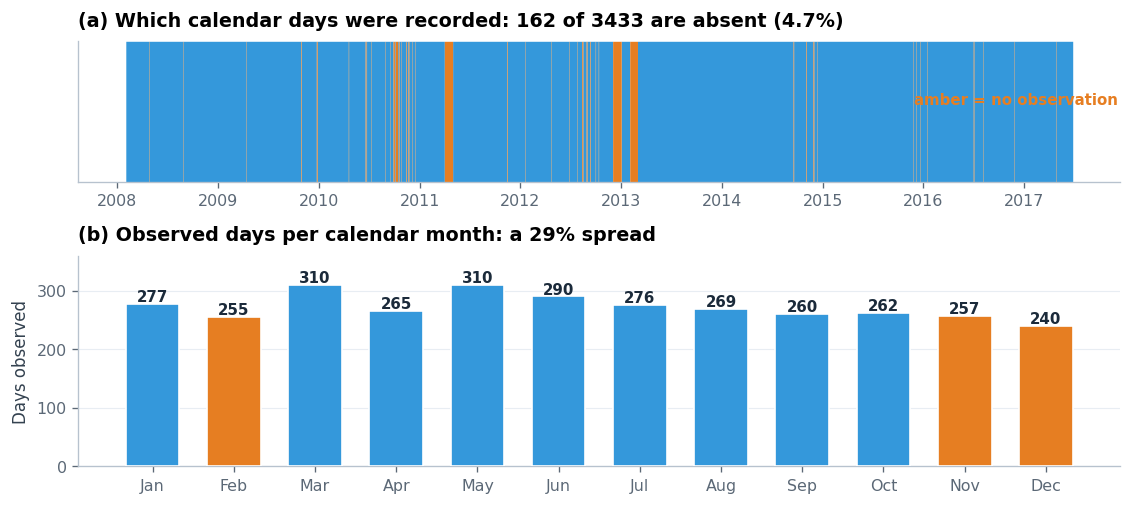

  figures/01_coverage.png


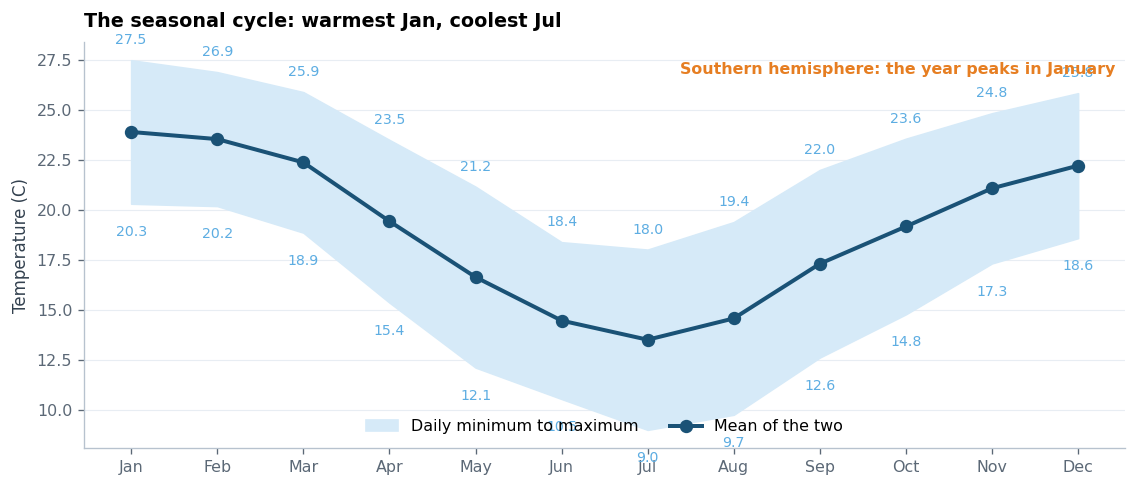

  figures/02_temperature_cycle.png


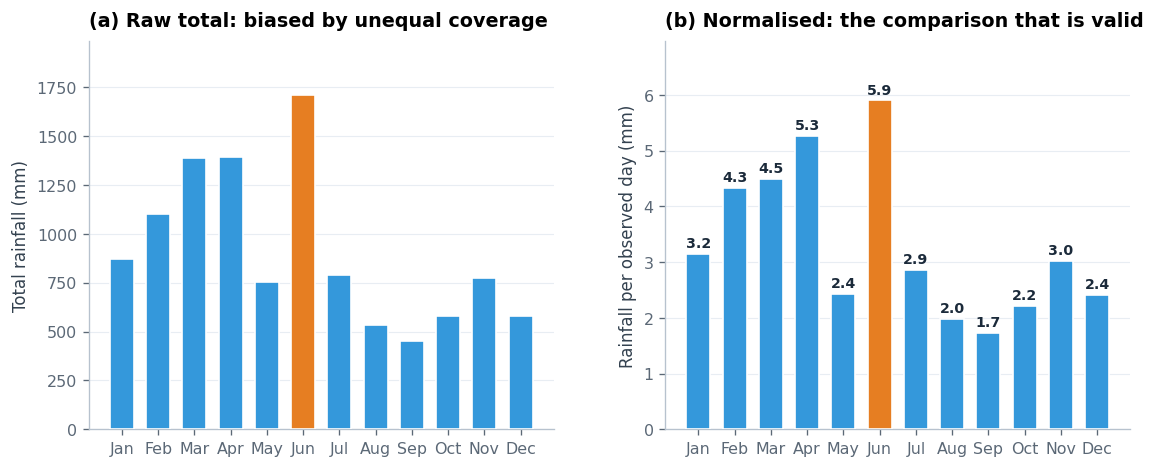

  figures/03_rainfall.png


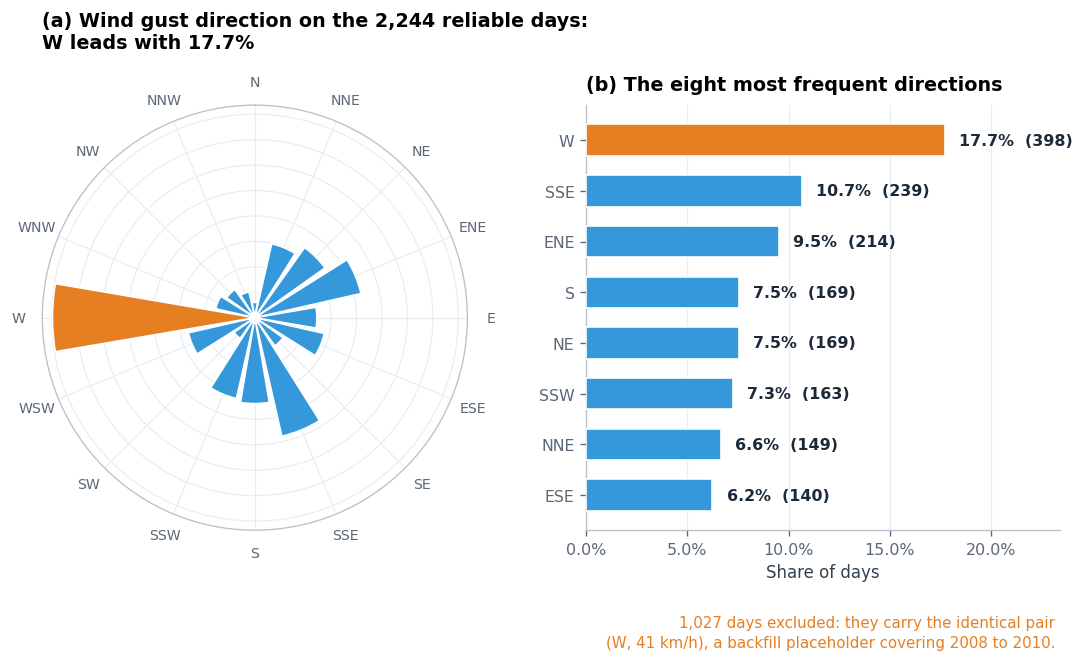

  figures/04_wind_rose.png


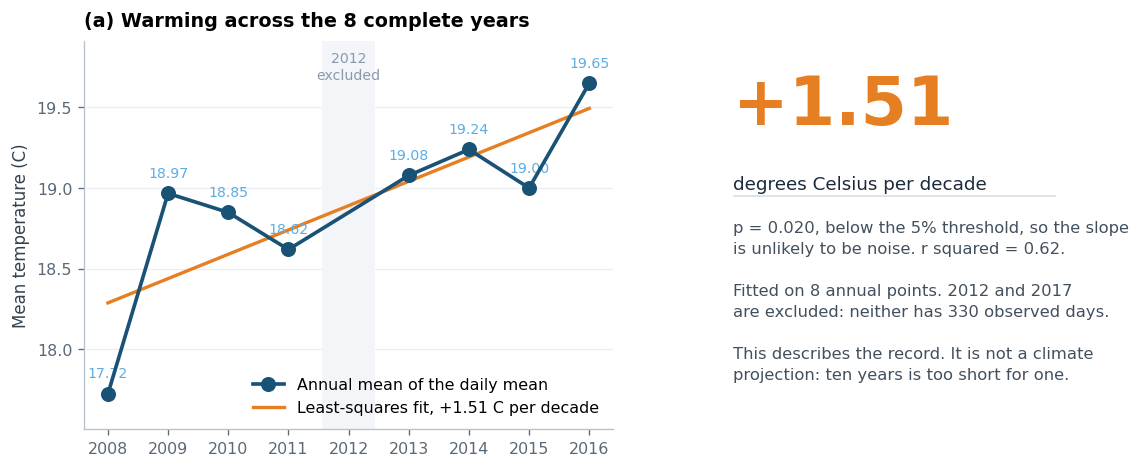

  figures/05_trend.png


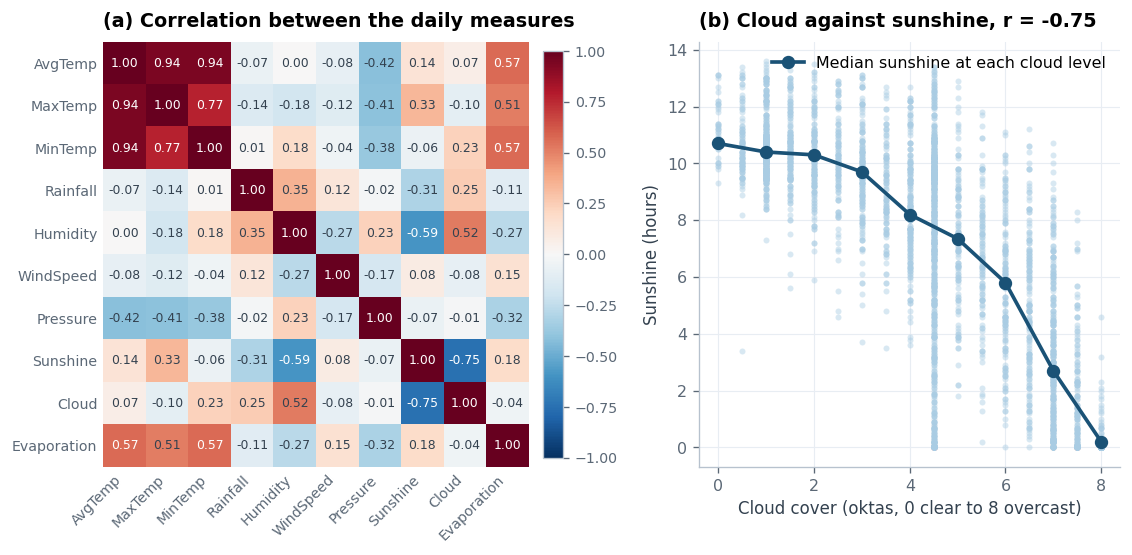

  figures/06_relationships.png

All six figures written. Findings saved to results/findings.json


In [8]:
# =============================================================================
# 6. FIGURES
# -----------------------------------------------------------------------------
# The chart type follows the data type. Every figure answers one question, and
# no reference line is dashed.
# =============================================================================
def save(fig, name):
    fig.savefig(f"figures/{name}.png"); plt.show(); plt.close(fig)
    print(f"  figures/{name}.png")
print("\nFIGURES")

# ---- Figure 1. Coverage: the gap a completeness audit cannot see -------------
fig, ax = plt.subplots(2, 1, figsize=(11.2, 4.6),
                       gridspec_kw={"height_ratios":[1, 1.5], "hspace":.42})
obs = pd.Series(1, index=df.Date).reindex(span, fill_value=0)
ax[0].fill_between(span, 0, obs.values, step="mid", color=BLUE, lw=0)
ax[0].fill_between(span, 0, 1-obs.values, step="mid", color=AMBER, lw=0)
ax[0].set_ylim(0, 1); ax[0].set_yticks([])
ax[0].set_title(f"(a) Which calendar days were recorded: "
                f"{F['missing_days']} of {F['span_days']} are absent "
                f"({F['missing_days_pct']}%)")
ax[0].grid(False)
ax[0].text(.998, .55, "amber = no observation", transform=ax[0].transAxes,
           ha="right", fontsize=9, color=AMBER, fontweight="bold")
dd = m.days
b = ax[1].bar(dd.index, dd.values, color=[AMBER if v < 260 else BLUE for v in dd.values],
              edgecolor="white", linewidth=1, zorder=3, width=.66)
for r_, v in zip(b, dd.values):
    ax[1].text(r_.get_x()+r_.get_width()/2, v+4, f"{v:.0f}", ha="center",
               fontsize=9, fontweight="bold", color=INK)
ax[1].set_ylim(0, dd.max()*1.16); ax[1].set_ylabel("Days observed")
ax[1].set_title(f"(b) Observed days per calendar month: a {F['coverage_spread_pct']:.0f}% spread")
ax[1].grid(axis="x", visible=False)
save(fig, "01_coverage")

# ---- Figure 2. The seasonal cycle of temperature -----------------------------
fig, ax = plt.subplots(figsize=(11.2, 4.4))
ax.fill_between(range(1,13), m.tmin, m.tmax, color=PALE, zorder=2,
                label="Daily minimum to maximum")
ax.plot(range(1,13), m.temp, "o-", color=NAVY, lw=2.4, ms=7, zorder=4,
        label="Mean of the two")
for i, (t, lo, hi) in enumerate(zip(m.temp, m.tmin, m.tmax), start=1):
    ax.text(i, hi+.8, f"{hi:.1f}", ha="center", fontsize=8.5, color=MID)
    ax.text(i, lo-1.6, f"{lo:.1f}", ha="center", fontsize=8.5, color=MID)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MN)
ax.set_ylabel("Temperature (C)")
ax.set_title(f"The seasonal cycle: warmest {F['warmest_month']}, coolest {F['coolest_month']}")
ax.legend(loc="lower center", ncol=2)
ax.grid(axis="x", visible=False)
ax.text(.99, .95, "Southern hemisphere: the year peaks in January",
        transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=AMBER,
        fontweight="bold")
save(fig, "02_temperature_cycle")

# ---- Figure 3. Rainfall, the two rankings side by side ----------------------
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2), gridspec_kw={"wspace":.24})
c1 = [AMBER if x == m.rain_total.max() else BLUE for x in m.rain_total]
b = ax[0].bar(m.index, m.rain_total, color=c1, edgecolor="white", linewidth=1,
              zorder=3, width=.66)
ax[0].set_ylim(0, m.rain_total.max()*1.16); ax[0].set_ylabel("Total rainfall (mm)")
ax[0].set_title("(a) Raw total: biased by unequal coverage")
ax[0].grid(axis="x", visible=False)
c2 = [AMBER if x == m.rain_per_day.max() else BLUE for x in m.rain_per_day]
b2 = ax[1].bar(m.index, m.rain_per_day, color=c2, edgecolor="white", linewidth=1,
               zorder=3, width=.66)
for r_, v in zip(b2, m.rain_per_day):
    ax[1].text(r_.get_x()+r_.get_width()/2, v+.12, f"{v:.1f}", ha="center",
               fontsize=8.5, fontweight="bold", color=INK)
ax[1].set_ylim(0, m.rain_per_day.max()*1.18)
ax[1].set_ylabel("Rainfall per observed day (mm)")
ax[1].set_title("(b) Normalised: the comparison that is valid")
ax[1].grid(axis="x", visible=False)
save(fig, "03_rainfall")

# ---- Figure 4. Wind rose -----------------------------------------------------
ORDER = ["N","NNE","NE","ENE","E","ESE","SE","SSE","S","SSW","SW","WSW","W","WNW","NW","NNW"]
counts = df.loc[~PLACEHOLDER, "WindGustDir"].value_counts().reindex(ORDER).fillna(0)
theta = np.linspace(0, 2*np.pi, 16, endpoint=False)
fig = plt.figure(figsize=(11.2, 4.6))
axp = fig.add_subplot(121, projection="polar")
cols = [AMBER if d_ == F["dominant_wind"] else BLUE for d_ in ORDER]
axp.bar(theta, counts.values, width=2*np.pi/16*.86, color=cols,
        edgecolor="white", linewidth=1, zorder=3)
axp.set_theta_zero_location("N"); axp.set_theta_direction(-1)
axp.set_xticks(theta); axp.set_xticklabels(ORDER, fontsize=8.5)
axp.set_yticklabels([]); axp.grid(color="#E8EDF3")
axp.set_title(f"(a) Wind gust direction on the {n_rel:,} reliable days:\n"
              f"{F['dominant_wind']} leads with {F['dominant_wind_pct']}%", pad=16)
ax2 = fig.add_subplot(122)
top = df.loc[~PLACEHOLDER, "WindGustDir"].value_counts().head(8).sort_values()
pct = 100*top/n_rel
bb = ax2.barh(top.index, pct, color=[AMBER if i == F["dominant_wind"] else BLUE
              for i in top.index], edgecolor="white", linewidth=1, zorder=3, height=.62)
for r_, v, n in zip(bb, pct, top):
    ax2.text(v+.7, r_.get_y()+r_.get_height()/2, f"{v:.1f}%  ({n})", va="center",
             fontsize=9.5, fontweight="bold", color=INK)
ax2.set_xlim(0, pct.max()*1.32); ax2.set_xlabel("Share of days")
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_title("(b) The eight most frequent directions")
ax2.text(.99, -.20, f"{F['wind_placeholder']['rows']:,} days excluded: they carry the identical pair\n"
         f"({F['wind_placeholder']['direction']}, {F['wind_placeholder']['speed']:.0f} km/h), a backfill placeholder covering 2008 to 2010.",
         transform=ax2.transAxes, ha="right", va="top", fontsize=9,
         color=AMBER, linespacing=1.4)
ax2.grid(axis="y", visible=False)
save(fig, "04_wind_rose")

# ---- Figure 5. The warming trend, tested not asserted ------------------------
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2),
                       gridspec_kw={"width_ratios":[1.35, 1], "wspace":.26})
ax[0].plot(ann.index, ann.temp, "o-", color=NAVY, lw=2.2, ms=8, zorder=4,
           label="Annual mean of the daily mean")
fit = ic + sl*np.array(ann.index)
ax[0].plot(ann.index, fit, color=AMBER, lw=2, zorder=3,
           label=f"Least-squares fit, {sl*10:+.2f} C per decade")
for x, y in zip(ann.index, ann.temp):
    ax[0].text(x, y+.10, f"{y:.2f}", ha="center", fontsize=8.5, color=MID)
# 2012 is absent from the series. The line joins 2011 to 2013 directly, which
# would imply continuity, so the gap is marked rather than left to be inferred.
gap_x = 2012
ax[0].axvspan(gap_x-.42, gap_x+.42, color="#F3F5F8", zorder=1)
ax[0].text(gap_x, ann.temp.max()+.20, "2012\nexcluded", ha="center", va="top",
           fontsize=8.5, color=GREY, linespacing=1.3, zorder=5)
ax[0].set_xticks(list(ann.index) + [gap_x])
ax[0].set_ylim(ann.temp.min()-.22, ann.temp.max()+.26)
ax[0].set_ylabel("Mean temperature (C)")
ax[0].set_title(f"(a) Warming across the {len(ann)} complete years")
ax[0].legend(loc="lower right", framealpha=1, facecolor="white", edgecolor="none")
ax[0].grid(axis="x", visible=False)
ax[1].set_xlim(0,1); ax[1].set_ylim(0,1); ax[1].axis("off")
ax[1].text(0, .92, f"{sl*10:+.2f}", fontsize=40, fontweight="bold", color=AMBER, va="top")
ax[1].text(0, .655, "degrees Celsius per decade", fontsize=11, color=INK, va="top")
ax[1].plot([0,.82],[.60,.60], color="#D6DEE7", lw=1)
ax[1].text(0, .54,
   f"p = {p:.3f}, below the 5% threshold, so the slope\n"
   f"is unlikely to be noise. r squared = {r**2:.2f}.\n\n"
   f"Fitted on {len(ann)} annual points. 2012 and 2017\n"
   f"are excluded: neither has 330 observed days.\n\n"
   "This describes the record. It is not a climate\n"
   "projection: ten years is too short for one.",
   fontsize=9.8, color="#42505E", va="top", linespacing=1.5)
save(fig, "05_trend")

# ---- Figure 6. What moves with what ------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.6),
                       gridspec_kw={"width_ratios":[1.15, 1], "wspace":.30})
im = ax[0].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(NUM))); ax[0].set_xticklabels(NUM, rotation=45, ha="right", fontsize=8.5)
ax[0].set_yticks(range(len(NUM))); ax[0].set_yticklabels(NUM, fontsize=8.5)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        v = corr.values[i, j]
        ax[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.4,
                   color="white" if abs(v) > .55 else "#33414F")
ax[0].set_title("(a) Correlation between the daily measures")
ax[0].grid(False)
for s_ in ax[0].spines.values(): s_.set_visible(False)
ax[0].tick_params(length=0)
fig.colorbar(im, ax=ax[0], fraction=.042, pad=.03).ax.tick_params(labelsize=8.5)

sub = df.dropna(subset=["Sunshine","Cloud"])
ax[1].scatter(sub.Cloud, sub.Sunshine, s=13, color=LIGHT, alpha=.45, linewidths=0, zorder=2)
cl = sub.groupby(sub.Cloud.round()).Sunshine.median()
ax[1].plot(cl.index, cl.values, "o-", color=NAVY, lw=2.2, ms=7, zorder=4,
           label="Median sunshine at each cloud level")
ax[1].set_xlabel("Cloud cover (oktas, 0 clear to 8 overcast)")
ax[1].set_ylabel("Sunshine (hours)")
rr = corr.loc["Sunshine","Cloud"]
ax[1].set_title(f"(b) Cloud against sunshine, r = {rr:+.2f}")
ax[1].legend(loc="upper right")
save(fig, "06_relationships")

json.dump(F, open("results/findings.json","w"), indent=2, default=str)
print("\nAll six figures written. Findings saved to results/findings.json")

<a id="ins"></a>
# 8. Insights

### 1. Nearly a third of the wind record is a placeholder

The pair *west, 41 km/h* covers 1,027 days, including **every day of 2008 and 2009**.
On the full file the prevailing wind appears westerly on 43.6% of days; on the
reliable days it is westerly on **17.7%**, ahead of south-south-east at 10.7%.

**Recommendation.** Treat wind gust as unusable before 2011, add a reliability flag to
the table, and run a constant-pair test on every instrument-derived column before
publishing from it.

### 2. The record is not the calendar

162 days carry no row, and whole months are absent. The observed-day count per
calendar month ranges from 240 to 310, a 29% spread.

Reported both ways, June is the wettest month and September the driest on the raw
total **and** on the per-day rate. The rankings agree, so the conclusion stands, but
that agreement was established rather than assumed.

**Recommendation.** Publish rainfall per observed day alongside the total, and show
the observed-day count beside any monthly figure.

### 3. The seasonal signal is southern hemisphere, and the sign matters

The warmest month is January, the coolest July. Applying the northern convention
would place the hottest quarter in winter and invert every seasonal statement. The
dashboard's humidity insight is exactly this error.

### 4. Warming of 1.51 °C per decade, significant but short

p = 0.020, r² = 0.62, on the eight complete years. The slope is unlikely to be noise,
and it is fitted on eight annual points at one station.

**Recommendation.** Report the slope with its p-value and its sample size, never the
slope alone.

### 5. Rain and warmth are in opposition

Autumn delivers 4.00 mm per observed day and winter 3.63, against 2.31 in spring.
June receives 3.4 times what September receives, while January is the warmest month.

### 6. Cloud and sunshine are one measurement taken twice

They correlate at −0.75, describing the same physical state from opposite directions.
The strongest relationship between genuinely distinct quantities is temperature
against evaporation at +0.57.

<a id="lim"></a>
# 9. Limitations

**No location.** The brief describes patterns across cities and countries. The file
has no city, country or station column, so no spatial comparison is possible.

**Wind before 2011 is unusable**, for the reason in insight 1. Every wind figure in
this notebook excludes the placeholder days, and that exclusion is stated wherever a
wind number appears.

**162 absent days**, clustered in 2010 to 2013 and removing whole months. Any figure
not normalised for observed days is biased by them.

**Eight years for a trend.** The slope is statistically significant and still rests on
eight annual points at one station. It describes this record and is not a projection.

**`RainToday` is derived.** It agrees with the rainfall column on every row, so it is
not an independent observation.

**Correlation, not causation.** Nothing here establishes why the measures covary.

#### Cell 9. Export the results

| | |
| :--- | :--- |
| **Input** | All tables and the findings. |
| **Method** | Writes the aggregate tables and `results/findings.json`, the file the report reads. |
| **Output** | The contents of `data/`, `figures/` and `results/`. |


In [9]:
json.dump(F, open('results/findings.json','w'), indent=2, default=str)
print('Written:')
for folder in ['data','figures','results']:
    for f in sorted(os.listdir(folder)): print(f'   {folder}/{f}')

Written:
   data/weather_clean.csv
   figures/01_coverage.png
   figures/02_temperature_cycle.png
   figures/03_rainfall.png
   figures/04_wind_rose.png
   figures/05_trend.png
   figures/06_relationships.png
   figures/07_powerbi_dashboard.png
   results/annual_means.csv
   results/correlation.csv
   results/findings.json
   results/monthly_profile.csv
   results/seasonal_profile.csv


#### Cell 10. Download the outputs

| | |
| :--- | :--- |
| **Input** | The files written above. |
| **Method** | Zips the figures and the results, then triggers a browser download. |
| **Output** | Three downloads. |

Without this cell the outputs stay in a session that disappears when the tab closes.


In [10]:
import shutil, sys
if "google.colab" in sys.modules:
    shutil.make_archive("figures", "zip", ".", "figures")
    shutil.make_archive("results", "zip", ".", "results")
    from google.colab import files
    files.download("data/weather_clean.csv")
    files.download("figures.zip"); files.download("results.zip")
    print("Three downloads triggered.")
else:
    print("Not in Colab. Outputs are on disk in data/, figures/ and results/.")

Not in Colab. Outputs are on disk in data/, figures/ and results/.


<a id="ref"></a>
# 10. References

- Bureau of Meteorology. *Observation of cloud: the okta scale*. Australian Government.
  http://www.bom.gov.au/
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. https://wesmckinney.com/book/
- Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10). https://vita.had.co.nz/papers/tidy-data.pdf
- Gebru, T., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. https://doi.org/10.1145/3458723
- Wilks, D. S. (2019). *Statistical Methods in the Atmospheric Sciences* (4th ed.). Elsevier.
- WMO (2018). *Guide to Instruments and Methods of Observation*, WMO-No. 8. World Meteorological Organization. https://library.wmo.int/

## Companion deliverables

`report.pdf` for the formal report, `INSIGHTS.md` for the conclusions,
`data/weather_clean.csv` for the cleaned dataset, `Weather_Dashboard.pbix` for the
Power BI dashboard.

## Author

**KOUAME Koffi Fidèle** · koffifidelek59@gmail.com